# DAY2 — 같은 입력으로 모델 교체 비교

ΔQ 분산 Feature 하나와 변환하지 않은 전체 수명 Target을 유지하고 Linear Regression, Ridge, Gradient Boosting을 비교한다. **목적은 대안을 구현하고 유지·교체 근거를 설명하는 것**이다.

Feature는 모델 입력, Target은 예측할 정답이다. CV는 개발 데이터를 번갈아 학습/검증하는 과정이며 fold는 그 한 회차다. OOF prediction은 해당 셀을 학습에서 제외한 회차의 예측이다. Hold-out은 후보 선택 이후 확인할 예약 데이터다. 이번에는 개발 29개만 사용한다.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/day2_dataset.py').is_file())
sys.path.insert(0, str(ROOT))
import pandas as pd
import numpy as np
from IPython.display import display, Image
from src.day2_boosting_comparison import configurations, run_comparison, paired_predictions, save_figures
print('Python:', sys.executable)
train = pd.read_parquet(ROOT / 'data/processed/day2/train_batch1.parquet')
dev = train.loc[train.partition.eq('development')].sort_values(['batch','cell_id']).reset_index(drop=True)
assert len(dev) == 29
assert dev.batch.eq("batch1").all()
display(dev[['cell_id','log10_deltaQ_var','cycle_life','cv_valid_fold']].head())

Python: /Users/soobin/myfolder/workspace/mini-project-data-analysis/.venv/bin/python


,cell_id,log10_deltaQ_var,cycle_life,cv_valid_fold
0,9,-4.059384,1054.0,4
1,11,-4.146897,788.0,5
2,14,-4.046070,880.0,2
3,15,-4.017949,719.0,2
4,16,-4.099414,862.0,3


## 비교 설정

Gradient Boosting은 여러 작은 트리를 차례로 학습해 이전 예측의 오차를 줄이는 모델이다. 최대 깊이 1/2, 트리 수 50/100을 비교한다. 각 리프(트리의 마지막 예측 구간)에 최소 10개 학습 셀을 두고 learning rate 0.05, random seed 42를 고정한다.

모든 모델은 같은 저장된 5-fold를 쓴다. StandardScaler는 학습 fold에서만 적합한다. 트리는 표준화가 필수는 아니지만 공통 Pipeline을 사용한다. Target 로그 변환이나 예측값 clipping은 수행하지 않는다.

In [2]:
display(pd.DataFrame(configurations()))
summary, scores, predictions, coefficients, scales, trees = run_comparison(dev)
paired = paired_predictions(predictions)
if (ROOT / 'outputs/tables/day2/boosting_comparison/summary.csv').exists():
    saved = pd.read_csv(ROOT / 'outputs/tables/day2/boosting_comparison/summary.csv')
    np.testing.assert_allclose(summary.set_index('config_id').sort_index().mean_fold_mape_pct,
                               saved.set_index('config_id').sort_index().mean_fold_mape_pct)
assert len(scores) == 30 and len(predictions) == 174
assert not predictions.duplicated(['config_id','barcode_key']).any()
display(summary[['config_id','mean_fold_mape_pct','std_fold_mape_pct','worst_fold_mape_pct','mean_fold_mae_cycles']])

,config_id,model,feature_set,target,alpha,max_depth,n_estimators
0,linear_regression,ols,variance_only,raw,NaN,NaN,NaN
1,ridge_a0.1,ridge,variance_only,raw,0.1,NaN,NaN
2,boosting_d1_n50,gradient_boosting,variance_only,raw,NaN,1.0,50.0
3,boosting_d1_n100,gradient_boosting,variance_only,raw,NaN,1.0,100.0
4,boosting_d2_n50,gradient_boosting,variance_only,raw,NaN,2.0,50.0
5,boosting_d2_n100,gradient_boosting,variance_only,raw,NaN,2.0,100.0


,config_id,mean_fold_mape_pct,std_fold_mape_pct,worst_fold_mape_pct,mean_fold_mae_cycles
0,ridge_a0.1,8.612355,2.001813,10.985726,69.840220
1,linear_regression,8.616772,1.991773,10.996753,69.889489
2,boosting_d1_n50,9.898976,4.363975,15.689004,74.412518
3,boosting_d2_n50,9.898976,4.363975,15.689004,74.412518
4,boosting_d1_n100,10.058383,4.268855,15.700588,75.907028
5,boosting_d2_n100,10.058383,4.268855,15.700588,75.907028


## 평균 오차와 회차별 편차

MAPE는 실제 수명에 대한 절대 오차 비율의 평균이다. 값이 낮을수록 오차가 작다. 아래 평균 CV MAPE는 5개 fold MAPE의 단순 평균이다. 오차 막대는 표본 표준편차이며 신뢰구간이 아니다.

config_id,boosting_d1_n100,boosting_d1_n50,boosting_d2_n100,boosting_d2_n50,linear_regression,ridge_a0.1
fold,,,,,,
1,8.799545,8.748406,8.799545,8.748406,6.493499,6.449655
2,8.828851,8.467119,8.828851,8.467119,10.996753,10.985726
3,4.420169,4.163935,4.420169,4.163935,7.643788,7.624592
4,12.542761,12.426418,12.542761,12.426418,10.473711,10.491077
5,15.700588,15.689004,15.700588,15.689004,7.476106,7.510724


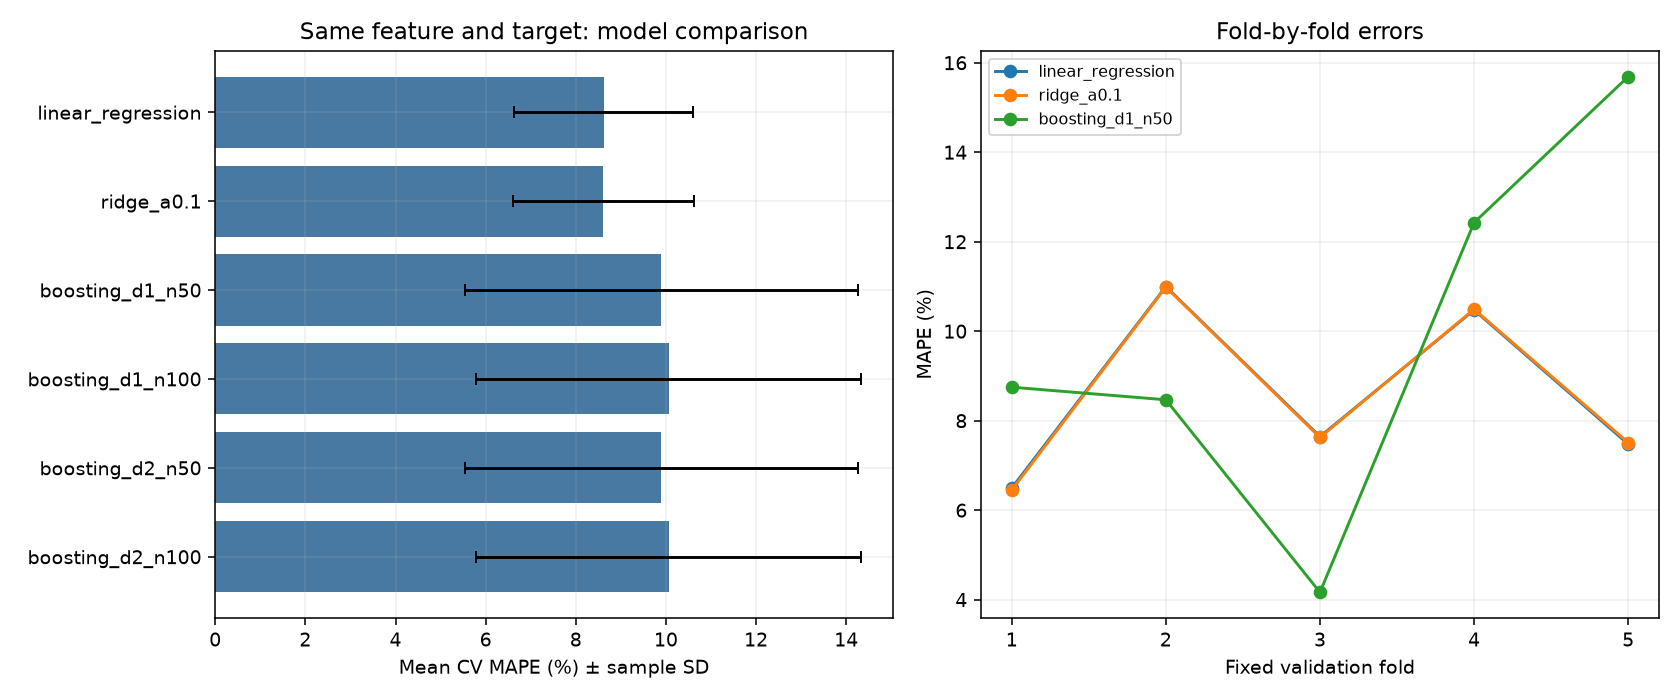

In [3]:
display(scores.pivot(index='fold',columns='config_id',values='mape_pct'))
best = summary.loc[summary.model.eq('gradient_boosting')].sort_values(['mean_fold_mape_pct', 'config_id']).iloc[0].config_id
save_figures(dev, summary, scores, predictions, best)
display(Image(filename=str(ROOT / 'outputs/figures/day2/boosting_comparison/01_model_comparison.png')))

## 셀별 변화

동일 셀의 Boosting 오차에서 선형 회귀 오차를 뺀다. 음수는 개선, 양수는 악화이며 단위는 %p이다. 셀별 평균과 fold 평균은 fold 표본 수가 달라 조금 다를 수 있다.

개선 셀: 15 / 전체 29


,cell_id,fold,actual_life,predicted_life_linear,predicted_life_alternative,ape_pct_linear,ape_pct_alternative,alternative_minus_linear_ape_pp
53,11,5,788.0,970.975263,876.987014,23.220211,11.292768,-11.927443
49,26,4,870.0,771.016134,853.611990,11.377456,1.883679,-9.493777
40,43,2,651.0,731.232386,673.470014,12.324483,3.451615,-8.872868


,cell_id,fold,actual_life,predicted_life_linear,predicted_life_alternative,ape_pct_linear,ape_pct_alternative,alternative_minus_linear_ape_pp
55,21,5,559.0,562.797002,690.458402,0.679249,23.516709,22.837460
54,20,5,534.0,571.456693,690.458402,7.014362,29.299326,22.284964
34,45,1,599.0,596.229651,680.971120,0.462496,13.684661,13.222165


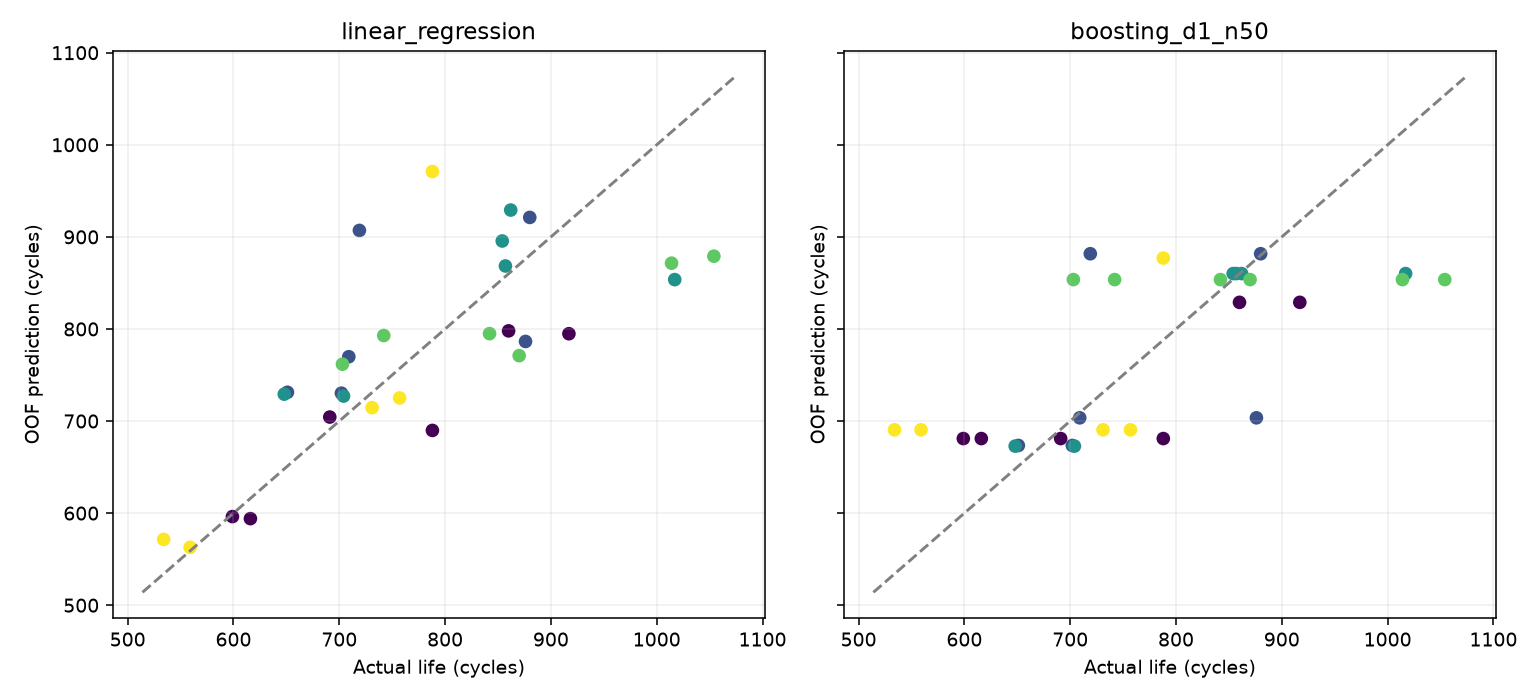

In [4]:
# best is determined from this execution's development CV
p = paired.loc[paired.config_id.eq(best)].copy()
print('개선 셀:', int((p.alternative_minus_linear_ape_pp < 0).sum()), '/ 전체', len(p))
cols = ['cell_id','fold','actual_life','predicted_life_linear','predicted_life_alternative','ape_pct_linear','ape_pct_alternative','alternative_minus_linear_ape_pp']
display(p.sort_values('alternative_minus_linear_ape_pp')[cols].head(3))
display(p.sort_values('alternative_minus_linear_ape_pp',ascending=False)[cols].head(3))
display(Image(filename=str(ROOT / 'outputs/figures/day2/boosting_comparison/02_oof_predictions.png')))

## 요청한 깊이와 실제 학습된 깊이

학습 fold에는 23–24개 셀이 있다. 리프마다 최소 10개를 요구하므로 3개 리프에 필요한 최소 30개가 없다. 따라서 깊이 2를 허용해도 실제 트리는 깊이 1에 머물렀다. 네 Boosting 설정은 실제로 트리 수에 따른 두 가지 결과만 만들었다.

In [5]:
display(trees.groupby('config_id').agg(max_actual_depth=('actual_depth','max'),max_leaves=('leaf_count','max'),min_leaf_samples=('min_observed_leaf_samples','min')))
assert trees.actual_depth.max() == 1
assert trees.min_observed_leaf_samples.min() >= 10
for n in [50, 100]:
    a = predictions.loc[predictions.config_id.eq(f'boosting_d1_n{n}')].sort_values('barcode_key').predicted_life
    b = predictions.loc[predictions.config_id.eq(f'boosting_d2_n{n}')].sort_values('barcode_key').predicted_life
    np.testing.assert_allclose(a, b)

,max_actual_depth,max_leaves,min_leaf_samples
config_id,,,
boosting_d1_n100,1,2,10
boosting_d1_n50,1,2,10
boosting_d2_n100,1,2,10
boosting_d2_n50,1,2,10


## 예측 관계의 형태

아래 그림은 해석을 위해 개발 29개 전체로 별도 적합한 모델 3개의 반응 곡선이다. **CV 검증 예측이나 성능 점수가 아니다.** 관측된 Feature 범위 안에서만 그렸다. 선형 회귀와 Ridge는 직선, 이 Boosting은 구간별로 일정한 예측을 만든다.

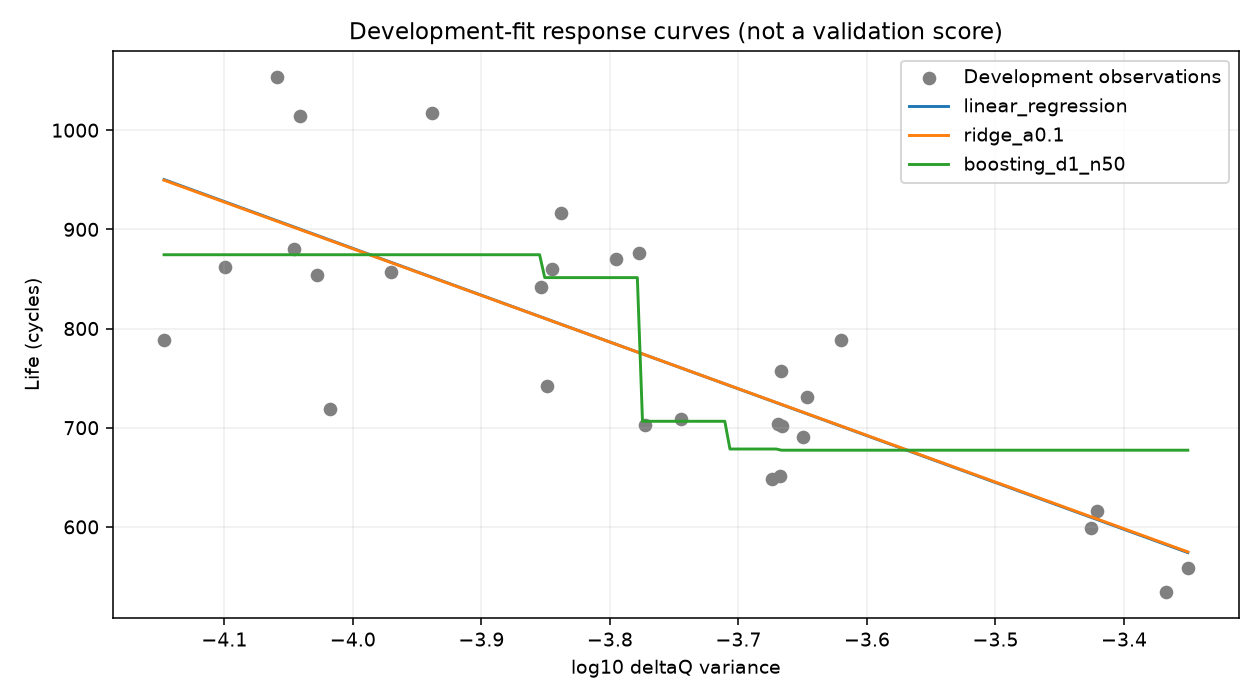

In [6]:
display(Image(filename=str(ROOT / 'outputs/figures/day2/boosting_comparison/03_response_curves.png')))

## 선택과 다음 단계

Linear Regression을 유지한다. 평균 CV MAPE는 8.62%, 가장 낮은 Boosting은 9.90%이며 Boosting의 fold 편차도 더 크다. Boosting이 15개 셀에서는 개선됐으나 일부 낮은 수명 셀의 큰 악화가 평균 오차를 높였다. Ridge 8.61%와의 작은 차이는 교체 근거로 삼지 않는다.

이는 현재 입력·표본·제약에서의 결정이다. 모든 Boosting 모델이 부적합하다거나 비선형 관계가 없다는 결론은 아니다. 여러 대안을 같은 CV로 선택했으므로 이 점수를 최종 일반화 성능으로 해석하지 않는다.

다음에는 선택 설정을 고정해 개발 29개로 학습하고 Hold-out 7개를 확인한다. 그다음 Batch 1의 36개로 재학습하여 Batch 2를 평가한다. 이번 노트북은 Hold-out과 Batch 2 성능을 계산하지 않는다.